# **AI-Based Battery State Estimation Algorithm Research**

**Project Overview:**

This notebook implements various machine learning algorithms for battery State of Health (SoH) estimation using the NASA Battery Aging Dataset. The research focuses on developing robust estimation algorithms through advanced feature engineering and comparative analysis of multiple ML approaches.

---

### **1. Package Loading and Environment Setup**

#### **1.1 Import Core Libraries**

In [35]:
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# File handling and utilities
import os
import glob
from pathlib import Path

### **2. Data Loading and Initial Inspectiion**

#### **2.1 Dataset Path Configuration**

In [36]:
# Define data paths
BASE_PATH = "cleaned_dataset"
METADATA_PATH = os.path.join(BASE_PATH, "metadata.csv")
DATA_FOLDER = os.path.join(BASE_PATH, "data")

# Verify paths exist
if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(f"Metadata file not found at: {METADATA_PATH}")
if not os.path.exists(DATA_FOLDER):
    raise FileNotFoundError(f"Data folder not found at: {DATA_FOLDER}")

print(f"Base path: {BASE_PATH}")
print(f"Metadata path: {METADATA_PATH}")
print(f"Data folder: {DATA_FOLDER}")

Base path: cleaned_dataset
Metadata path: cleaned_dataset/metadata.csv
Data folder: cleaned_dataset/data


#### **2.2 Metadata Loading and Inspection**

In [37]:
# Load metadata
metadata = pd.read_csv(METADATA_PATH)

print("Metadata Dataset Information (Before Type Conversion):")
print("=" * 50)
print(f"Dataset shape: {metadata.shape}")
print(f"Memory usage: {metadata.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn information:")
print(metadata.dtypes)
print("\n" + "=" * 50)

# Display first few rows of metadata
print("First few rows of metadata:")
display(metadata.head())

Metadata Dataset Information (Before Type Conversion):
Dataset shape: (7565, 10)
Memory usage: 3.35 MB

Column information:
type                   object
start_time             object
ambient_temperature     int64
battery_id             object
test_id                 int64
uid                     int64
filename               object
Capacity               object
Re                     object
Rct                    object
dtype: object

First few rows of metadata:


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


#### **2.3 Data Type Optimization**

In [38]:
def parse_start_time(time_val):
    """Parse custom start_time format from either string or list/array"""
    try:
        # If it's a string like '[2010. 7. 22. 6. 16. 21.781]'
        if isinstance(time_val, str):
            parts = time_val.strip('[]').split()
            parts = [float(p) for p in parts if p.strip()]
        
        # If it's already a list/array of floats
        elif isinstance(time_val, (list, np.ndarray)):
            parts = list(map(float, time_val))
        
        else:
            return pd.NaT

        if len(parts) >= 6:
            year, month, day, hour, minute, second = parts[:6]
            return pd.Timestamp(
                year=int(year),
                month=int(month),
                day=int(day),
                hour=int(hour),
                minute=int(minute),
                second=int(second),
                microsecond=int((second - int(second)) * 1_000_000)
            )
    except Exception as e:
        return pd.NaT

metadata['start_time_parsed'] = metadata['start_time'].apply(parse_start_time)

# Check conversion success
conversion_success = metadata['start_time_parsed'].notna().sum()
print(f"Successfully converted {conversion_success}/{len(metadata)} start_time values")

# If conversion worked well, replace the original column
if conversion_success > len(metadata) * 0.9:  # If >90% success
    metadata['start_time'] = metadata['start_time_parsed']
    metadata.drop('start_time_parsed', axis=1, inplace=True)
    print("Start_time conversion successful")
else:
    print("Start_time conversion had issues, keeping both columns for inspection")

# Convert battery_id to string (ensure consistency)
metadata['battery_id'] = metadata['battery_id'].astype(str)

# Convert ambient_temperature to float (in case of decimal values)
metadata['ambient_temperature'] = pd.to_numeric(metadata['ambient_temperature'], errors='coerce')

# Convert Capacity to float (handle any non-numeric values)
metadata['Capacity'] = pd.to_numeric(metadata['Capacity'], errors='coerce')

# Convert Re (resistance) to float
metadata['Re'] = pd.to_numeric(metadata['Re'], errors='coerce')

# Convert Rct (resistance) to float  
metadata['Rct'] = pd.to_numeric(metadata['Rct'], errors='coerce')

print("\nMetadata Dataset Information (After Type Conversion):")
print("=" * 50)
print(f"Dataset shape: {metadata.shape}")
print(f"Memory usage: {metadata.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nUpdated column information:")
print(metadata.dtypes)
print("\n" + "=" * 50)

# Check for any conversion issues
print("\nChecking for conversion issues:")
columns_to_check = ['start_time', 'ambient_temperature', 'Capacity', 'Re', 'Rct']
for col in columns_to_check:
    if col in metadata.columns:
        null_count = metadata[col].isnull().sum()
        if null_count > 0:
            print(f"{col}: {null_count} null values after conversion")
        else:
            print(f"{col}: No null values")

Successfully converted 7565/7565 start_time values
Start_time conversion successful

Metadata Dataset Information (After Type Conversion):
Dataset shape: (7565, 10)
Memory usage: 1.80 MB

Updated column information:
type                           object
start_time             datetime64[ns]
ambient_temperature             int64
battery_id                     object
test_id                         int64
uid                             int64
filename                       object
Capacity                      float64
Re                            float64
Rct                           float64
dtype: object


Checking for conversion issues:
start_time: No null values
ambient_temperature: No null values
Capacity: 4796 null values after conversion
Re: 5618 null values after conversion
Rct: 5618 null values after conversion


#### **2.3 Metadata Exploration**

In [39]:
# Display first few rows
print("First 5 rows of metadata:")
display(metadata.head())

print("\nMetadata Statistical Summary:")
display(metadata.describe())

print("\nUnique values per column:")
for col in metadata.columns:
    unique_count = metadata[col].nunique()
    print(f"{col}: {unique_count} unique values")

print("\nMissing values:")
missing_data = metadata.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.any() else "No missing values found")

First 5 rows of metadata:


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,2010-07-21 15:00:35.093000,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,2010-07-21 16:53:45.968000,24,B0047,1,2,00002.csv,NaN,0.056058,0.200970
2,charge,2010-07-21 17:25:40.670999,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,2010-07-21 20:31:05.000000,24,B0047,3,4,00004.csv,NaN,0.053192,0.164734
4,discharge,2010-07-21 21:02:56.984000,4,B0047,4,5,00005.csv,1.524366,NaN,NaN



Metadata Statistical Summary:


,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct
count,7565,7565.000000,7565.000000,7565.000000,2769.000000,1.947000e+03,1.947000e+03
mean,2009-08-14 03:15:31.312608512,20.017713,176.012558,3783.000000,1.326543,-4.976500e+11,1.055903e+12
min,2008-04-02 13:08:17.920999,4.000000,0.000000,1.000000,0.000000,-9.689245e+14,-2.091081e+02
25%,2008-07-11 18:25:27.592999936,4.000000,55.000000,1892.000000,1.150286,5.782157e-02,8.155754e-02
50%,2009-08-02 09:10:15.045999104,24.000000,129.000000,3783.000000,1.428065,7.255344e-02,1.014191e-01
75%,2010-06-30 09:21:28.343000064,24.000000,255.000000,5674.000000,1.673645,9.229960e-02,1.565123e-01
max,2010-09-30 15:32:33.078000,44.000000,615.000000,7565.000000,2.640149,4.482291e+02,2.055843e+15
std,NaN,11.082914,152.174147,2183.971726,0.472517,2.195872e+13,4.659154e+13



Unique values per column:
type: 3 unique values
start_time: 2494 unique values
ambient_temperature: 5 unique values
battery_id: 34 unique values
test_id: 616 unique values
uid: 7565 unique values
filename: 7565 unique values
Capacity: 2751 unique values
Re: 1947 unique values
Rct: 1947 unique values

Missing values:
Capacity    4796
Re          5618
Rct         5618
dtype: int64


#### **2.4 Battery and Cycle Type Analysis**

Battery Distribution:
battery_id
B0005    616
B0006    616
B0007    616
B0018    319
B0025     80
B0026     80
B0027     80
B0028     80
B0029     97
B0030     97
B0031     97
B0032     97
B0033    486
B0034    486
B0036    486
B0038    122
B0039    122
B0040    122
B0041    163
B0042    275
B0043    275
B0044    275
B0045    184
B0046    184
B0047    184
B0048    184
B0049     62
B0050     62
B0051     62
B0052     62
B0053    137
B0054    253
B0055    252
B0056    252
Name: count, dtype: int64

Total number of batteries: 34
Total number of cycles: 7565

⚡ Cycle Type Distribution:
type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64


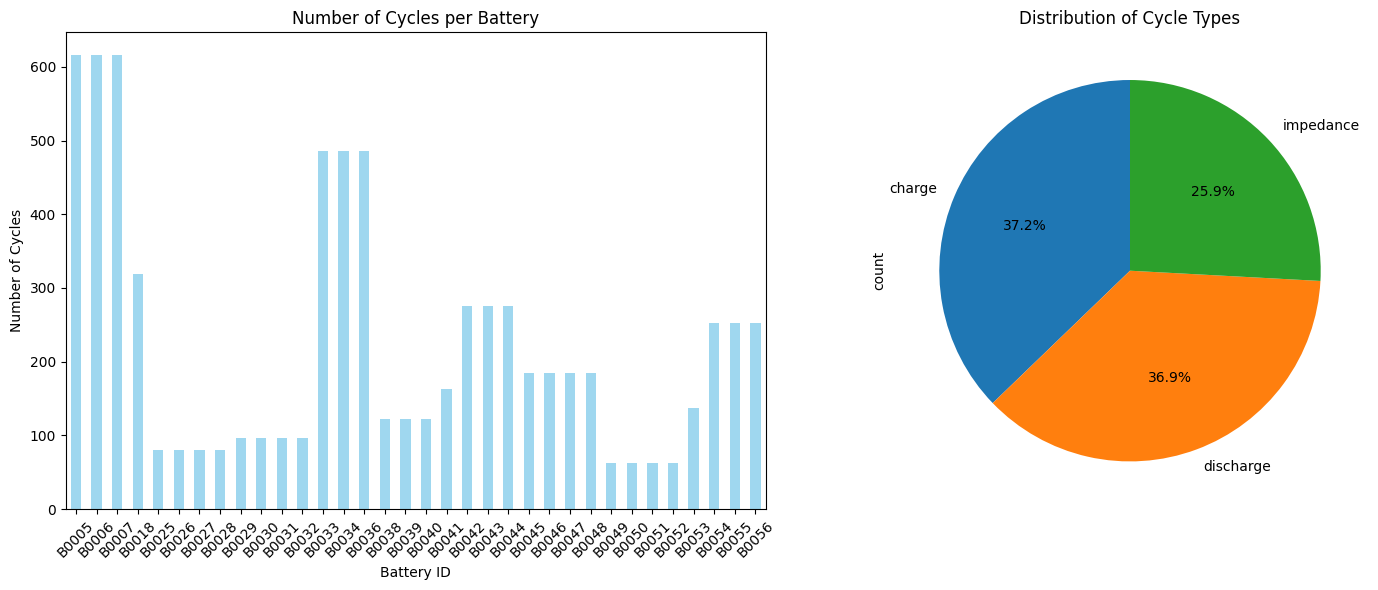

In [40]:
# Analyze battery distribution
print("Battery Distribution:")
battery_counts = metadata['battery_id'].value_counts().sort_index()
print(battery_counts)

print(f"\nTotal number of batteries: {metadata['battery_id'].nunique()}")
print(f"Total number of cycles: {len(metadata)}")

# Analyze cycle types
print("\n⚡ Cycle Type Distribution:")
cycle_type_counts = metadata['type'].value_counts()
print(cycle_type_counts)

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Battery distribution
battery_counts.plot(kind='bar', ax=axes[0], color='skyblue', alpha=0.8)
axes[0].set_title('Number of Cycles per Battery')
axes[0].set_xlabel('Battery ID')
axes[0].set_ylabel('Number of Cycles')
axes[0].tick_params(axis='x', rotation=45)

# Cycle type distribution
cycle_type_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribution of Cycle Types')

plt.tight_layout()
plt.show()

### **3. Data Quality Assesment**

#### **3.1 Identify Problematic Batteries**

In [41]:
# Analyze battery cycle patterns to identify potential issues
battery_analysis = []

for battery_id in metadata['battery_id'].unique():
    battery_data = metadata[metadata['battery_id'] == battery_id]
    
    analysis = {
        'battery_id': battery_id,
        'total_cycles': len(battery_data),
        'discharge_cycles': len(battery_data[battery_data['type'] == 'discharge']),
        'charge_cycles': len(battery_data[battery_data['type'] == 'charge']),
        'impedance_cycles': len(battery_data[battery_data['type'] == 'impedance']),
        'first_cycle_date': battery_data['filename'].min() if not battery_data.empty else None,
        'last_cycle_date': battery_data['filename'].max() if not battery_data.empty else None
    }
    battery_analysis.append(analysis)

battery_df = pd.DataFrame(battery_analysis)

print("Battery Analysis Summary:")
display(battery_df)

# Identify batteries with insufficient discharge cycles
min_discharge_threshold = 25  # Minimum discharge cycles for meaningful analysis
insufficient_batteries = battery_df[battery_df['discharge_cycles'] <= min_discharge_threshold]['battery_id'].tolist()

print(f"\nBatteries with ≤ {min_discharge_threshold} discharge cycles:")
print(insufficient_batteries)

Battery Analysis Summary:


,battery_id,total_cycles,discharge_cycles,charge_cycles,impedance_cycles,first_cycle_date,last_cycle_date
0,B0047,184,72,72,40,00001.csv,00184.csv
1,B0045,184,72,72,40,00185.csv,00368.csv
2,B0048,184,72,72,40,00369.csv,00552.csv
3,B0046,184,72,72,40,00553.csv,00736.csv
4,B0043,275,112,113,50,00737.csv,01011.csv
5,B0032,97,40,40,17,01012.csv,01108.csv
6,B0039,122,47,47,28,01109.csv,01230.csv
7,B0040,122,47,47,28,01231.csv,01352.csv
8,B0029,97,40,40,17,01353.csv,01449.csv
9,B0028,80,28,31,21,01450.csv,01529.csv



Batteries with ≤ 25 discharge cycles:
['B0049', 'B0050', 'B0052', 'B0051']


#### **3.2 Sample Data File Inspection**

Inspecting sample file: 05122.csv
Battery: B0005

Sample data shape: (197, 6)

Column information:
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
Current_load            float64
Voltage_load            float64
Time                    float64
dtype: object

First 5 rows:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000
1,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781
2,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703
3,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781
4,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922



Statistical summary:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,3.529829,-1.818702,32.572328,-1.805570,2.404944,1812.087497
std,0.236558,0.595058,3.495804,0.591217,0.796974,1069.272600
min,2.612467,-2.018015,24.325993,-1.998400,0.000000,0.000000
25%,3.418746,-2.013447,30.422589,-1.998200,2.498000,891.812000
50%,3.529903,-2.012427,32.865786,-1.998200,2.610000,1796.328000
75%,3.685214,-2.011144,35.095568,-1.998200,2.765000,2724.203000
max,4.191492,0.000729,38.982181,-0.000400,4.206000,3690.234000


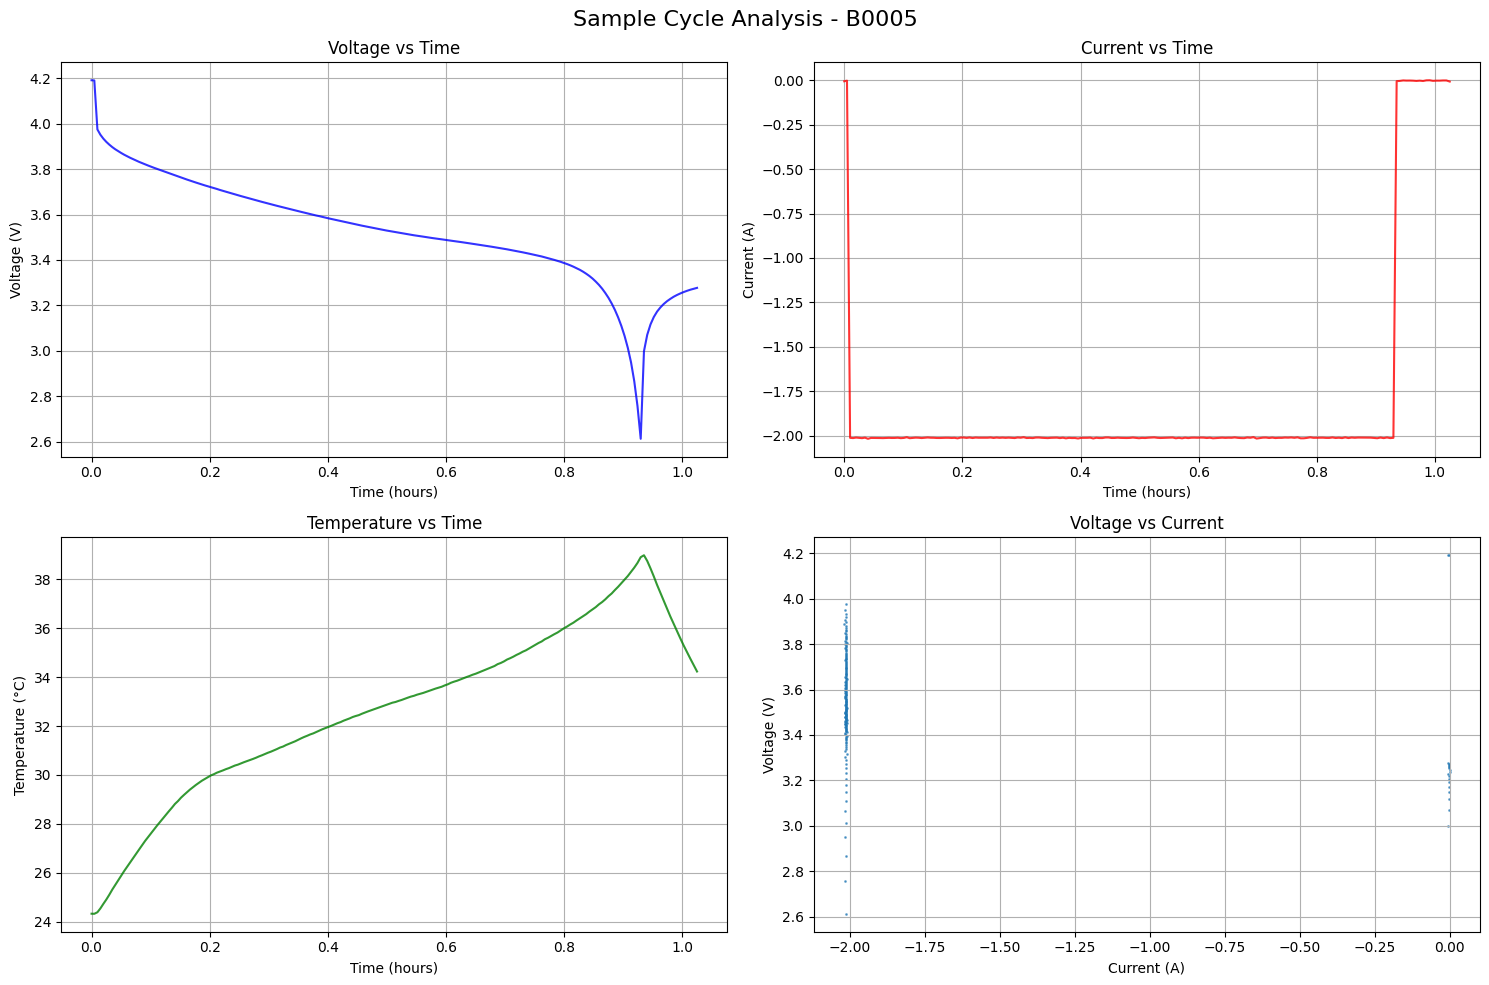

In [42]:
# Load a sample data file to understand structure (from a good battery)
good_battery_metadata = metadata[
    (metadata['type'] == 'discharge') & 
    (metadata['battery_id'] == 'B0005')  # Known good battery with many cycles
].iloc[0]

sample_file_path = os.path.join(DATA_FOLDER, good_battery_metadata['filename'])

print(f"Inspecting sample file: {good_battery_metadata['filename']}")
print(f"Battery: {good_battery_metadata['battery_id']}")

sample_data = pd.read_csv(sample_file_path)

print(f"\nSample data shape: {sample_data.shape}")
print("\nColumn information:")
print(sample_data.dtypes)

print("\nFirst 5 rows:")
display(sample_data.head())

print("\nStatistical summary:")
display(sample_data.describe())

# Visualize sample cycle
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Voltage vs Time
axes[0,0].plot(sample_data['Time']/3600, sample_data['Voltage_measured'], 'b-', alpha=0.8)
axes[0,0].set_xlabel('Time (hours)')
axes[0,0].set_ylabel('Voltage (V)')
axes[0,0].set_title('Voltage vs Time')
axes[0,0].grid(True)

# Current vs Time
axes[0,1].plot(sample_data['Time']/3600, sample_data['Current_measured'], 'r-', alpha=0.8)
axes[0,1].set_xlabel('Time (hours)')
axes[0,1].set_ylabel('Current (A)')
axes[0,1].set_title('Current vs Time')
axes[0,1].grid(True)

# Temperature vs Time
axes[1,0].plot(sample_data['Time']/3600, sample_data['Temperature_measured'], 'g-', alpha=0.8)
axes[1,0].set_xlabel('Time (hours)')
axes[1,0].set_ylabel('Temperature (°C)')
axes[1,0].set_title('Temperature vs Time')
axes[1,0].grid(True)

# Voltage vs Current
axes[1,1].scatter(sample_data['Current_measured'], sample_data['Voltage_measured'], alpha=0.6, s=1)
axes[1,1].set_xlabel('Current (A)')
axes[1,1].set_ylabel('Voltage (V)')
axes[1,1].set_title('Voltage vs Current')
axes[1,1].grid(True)

plt.suptitle(f'Sample Cycle Analysis - {good_battery_metadata["battery_id"]}', fontsize=16)
plt.tight_layout()
plt.show()

Inspecting sample file: 00001.csv
Battery: B0047

Sample data shape: (490, 6)

Column information:
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
Current_load            float64
Voltage_load            float64
Time                    float64
dtype: object

First 5 rows:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625



Statistical summary:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
count,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
mean,3.475266,-0.952767,8.272423,0.957153,2.817939,3205.134141
std,0.284626,0.201448,1.455269,0.202690,0.644985,1861.395346
min,2.470612,-1.001101,5.008084,0.000200,0.000000,0.000000
25%,3.336993,-0.995898,7.313213,1.000000,2.790500,1598.417750
50%,3.491946,-0.995207,8.184590,1.000000,2.945500,3200.492500
75%,3.655987,-0.994648,9.025544,1.000000,3.105750,4809.176250
max,4.246764,0.000252,12.376816,1.000000,4.262000,6436.141000


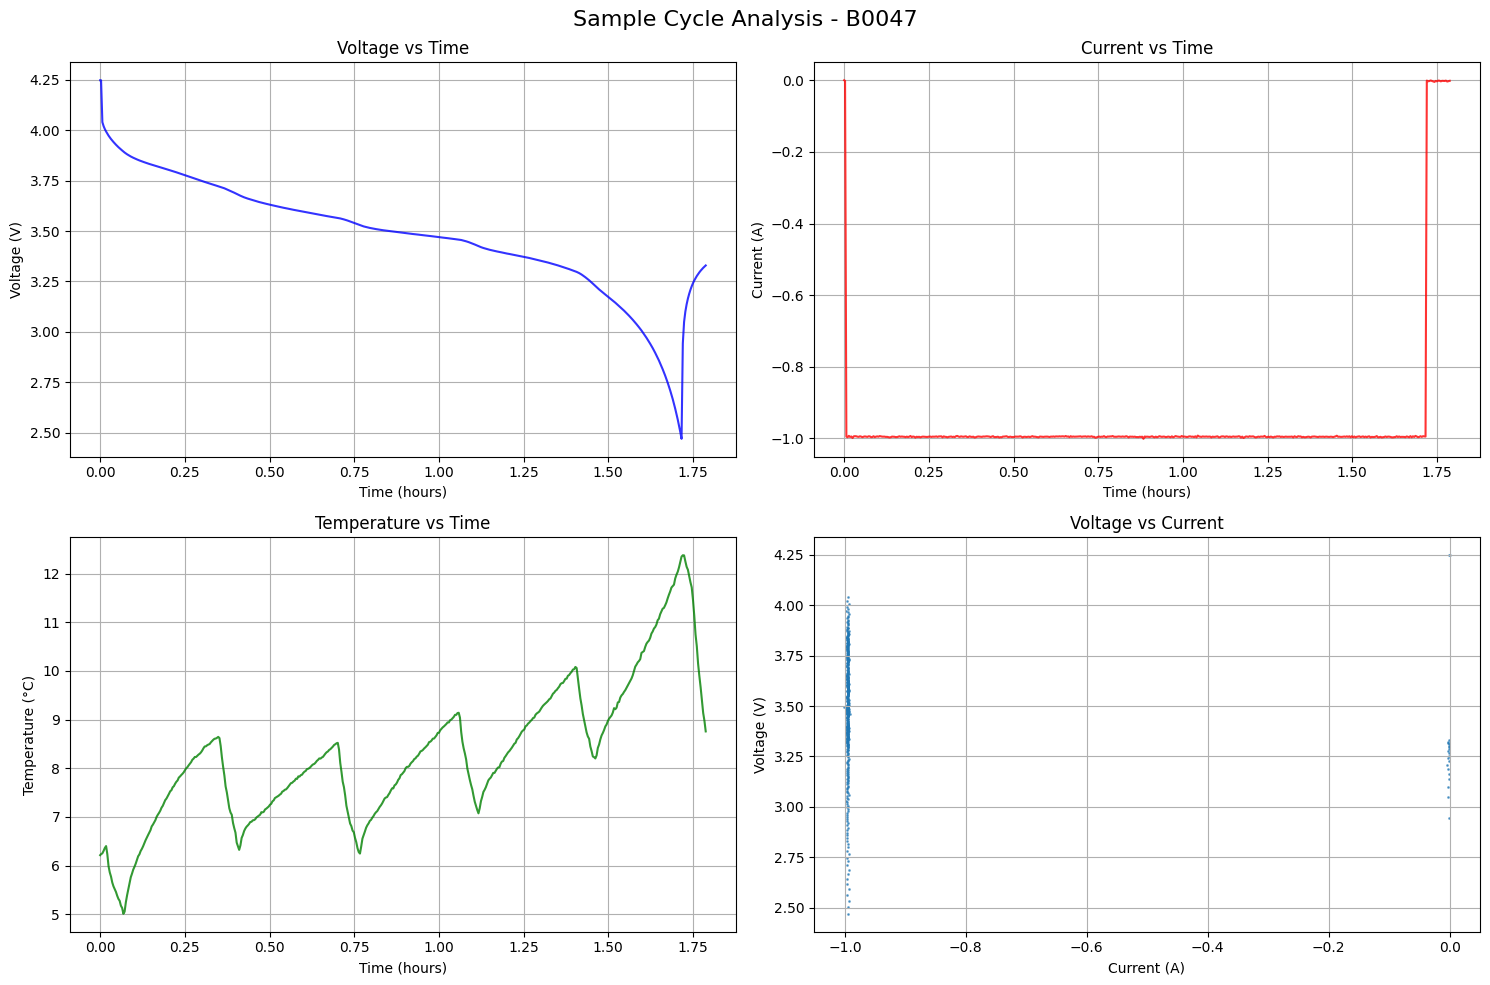

In [43]:
# Load a sample data file to understand structure
sample_metadata = metadata[metadata['type'] == 'discharge'].iloc[0]
sample_file_path = os.path.join(DATA_FOLDER, sample_metadata['filename'])

print(f"Inspecting sample file: {sample_metadata['filename']}")
print(f"Battery: {sample_metadata['battery_id']}")

sample_data = pd.read_csv(sample_file_path)

print(f"\nSample data shape: {sample_data.shape}")
print("\nColumn information:")
print(sample_data.dtypes)

print("\nFirst 5 rows:")
display(sample_data.head())

print("\nStatistical summary:")
display(sample_data.describe())

# Visualize sample cycle
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Voltage vs Time
axes[0,0].plot(sample_data['Time']/3600, sample_data['Voltage_measured'], 'b-', alpha=0.8)
axes[0,0].set_xlabel('Time (hours)')
axes[0,0].set_ylabel('Voltage (V)')
axes[0,0].set_title('Voltage vs Time')
axes[0,0].grid(True)

# Current vs Time
axes[0,1].plot(sample_data['Time']/3600, sample_data['Current_measured'], 'r-', alpha=0.8)
axes[0,1].set_xlabel('Time (hours)')
axes[0,1].set_ylabel('Current (A)')
axes[0,1].set_title('Current vs Time')
axes[0,1].grid(True)

# Temperature vs Time
axes[1,0].plot(sample_data['Time']/3600, sample_data['Temperature_measured'], 'g-', alpha=0.8)
axes[1,0].set_xlabel('Time (hours)')
axes[1,0].set_ylabel('Temperature (°C)')
axes[1,0].set_title('Temperature vs Time')
axes[1,0].grid(True)

# Voltage vs Current
axes[1,1].scatter(sample_data['Current_measured'], sample_data['Voltage_measured'], alpha=0.6, s=1)
axes[1,1].set_xlabel('Current (A)')
axes[1,1].set_ylabel('Voltage (V)')
axes[1,1].set_title('Voltage vs Current')
axes[1,1].grid(True)

plt.suptitle(f'Sample Cycle Analysis - {sample_metadata["battery_id"]}', fontsize=16)
plt.tight_layout()
plt.show()

### **4. Data Filtering and Selection**

#### **4.1 Battery Selection Analysis**

In [44]:
# Analyze different threshold options
cycle_thresholds = [25, 40, 50, 70, 100]

print("Impact of Different Cycle Thresholds:")
print("=" * 60)

threshold_analysis = []
for threshold in cycle_thresholds:
    qualifying_batteries = battery_df[battery_df['discharge_cycles'] >= threshold]
    total_cycles = qualifying_batteries['discharge_cycles'].sum()
    
    analysis = {
        'threshold': threshold,
        'num_batteries': len(qualifying_batteries),
        'total_cycles': total_cycles,
        'avg_cycles_per_battery': total_cycles / len(qualifying_batteries) if len(qualifying_batteries) > 0 else 0,
        'qualifying_batteries': qualifying_batteries['battery_id'].tolist()
    }
    threshold_analysis.append(analysis)
    
    print(f"Threshold ≥{threshold}: {len(qualifying_batteries)} batteries, {total_cycles} total cycles")

# Create comparison DataFrame
threshold_df = pd.DataFrame(threshold_analysis)
print(f"\nThreshold Analysis Summary:")
display(threshold_df[['threshold', 'num_batteries', 'total_cycles', 'avg_cycles_per_battery']])

Impact of Different Cycle Thresholds:
Threshold ≥25: 34 batteries, 2794 total cycles
Threshold ≥40: 26 batteries, 2582 total cycles
Threshold ≥50: 19 batteries, 2281 total cycles
Threshold ≥70: 17 batteries, 2158 total cycles
Threshold ≥100: 13 batteries, 1870 total cycles

Threshold Analysis Summary:


,threshold,num_batteries,total_cycles,avg_cycles_per_battery
0,25,34,2794,82.176471
1,40,26,2582,99.307692
2,50,19,2281,120.052632
3,70,17,2158,126.941176
4,100,13,1870,143.846154


#### **4.2 Battery Selection**

In [45]:
RECOMMENDED_THRESHOLD = 25

# Get batteries meeting threshold
sufficient_cycle_batteries = battery_df[battery_df['discharge_cycles'] >= RECOMMENDED_THRESHOLD]['battery_id'].tolist()

# Final battery selection (exclude known problematic + insufficient cycles)
all_excluded = battery_df[battery_df['discharge_cycles'] <= RECOMMENDED_THRESHOLD]['battery_id'].tolist()

print("Final Battery Selection Strategy:")
print("=" * 50)
print(f"Minimum cycle threshold: {RECOMMENDED_THRESHOLD}")
print(f"\nExcluded batteries ({len(all_excluded)}): {all_excluded}")

# Apply filtering
filtered_metadata = metadata[
    (metadata['type'] == 'discharge') &
    (~metadata['battery_id'].isin(all_excluded))
].copy()

selected_batteries = sorted(filtered_metadata['battery_id'].unique())
print(f"\nSelected batteries ({len(selected_batteries)}): {selected_batteries}")

print(f"\nFinal Dataset Summary:")
print(f"Total discharge cycles available: {len(filtered_metadata)}")
print(f"Average cycles per battery: {len(filtered_metadata) / len(selected_batteries):.1f}")

# Show selected battery details
selected_summary = battery_df[battery_df['battery_id'].isin(selected_batteries)].copy()
selected_summary = selected_summary.sort_values('discharge_cycles', ascending=False)
print(f"\nSelected Battery Details:")
display(selected_summary[['battery_id', 'discharge_cycles', 'total_cycles']])

Final Battery Selection Strategy:
Minimum cycle threshold: 25

Excluded batteries (4): ['B0049', 'B0050', 'B0052', 'B0051']

Selected batteries (30): ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0053', 'B0054', 'B0055', 'B0056']

Final Dataset Summary:
Total discharge cycles available: 2694
Average cycles per battery: 89.8

Selected Battery Details:


,battery_id,discharge_cycles,total_cycles
11,B0034,197,486
13,B0033,197,486
18,B0036,197,486
26,B0006,168,616
28,B0007,168,616
27,B0005,168,616
29,B0018,132,319
4,B0043,112,275
17,B0044,112,275
10,B0042,112,275


#### **4.3 Cycle Numbering and Organization**

Cycle Distribution per Battery:


,total_cycles,max_cycle_num,first_file
battery_id,,,
B0034,197,197,01805.csv
B0033,197,197,02413.csv
B0036,197,197,03514.csv
B0007,168,168,05738.csv
B0005,168,168,05122.csv
B0006,168,168,04506.csv
B0018,132,132,06355.csv
B0042,112,112,01532.csv
B0044,112,112,03241.csv


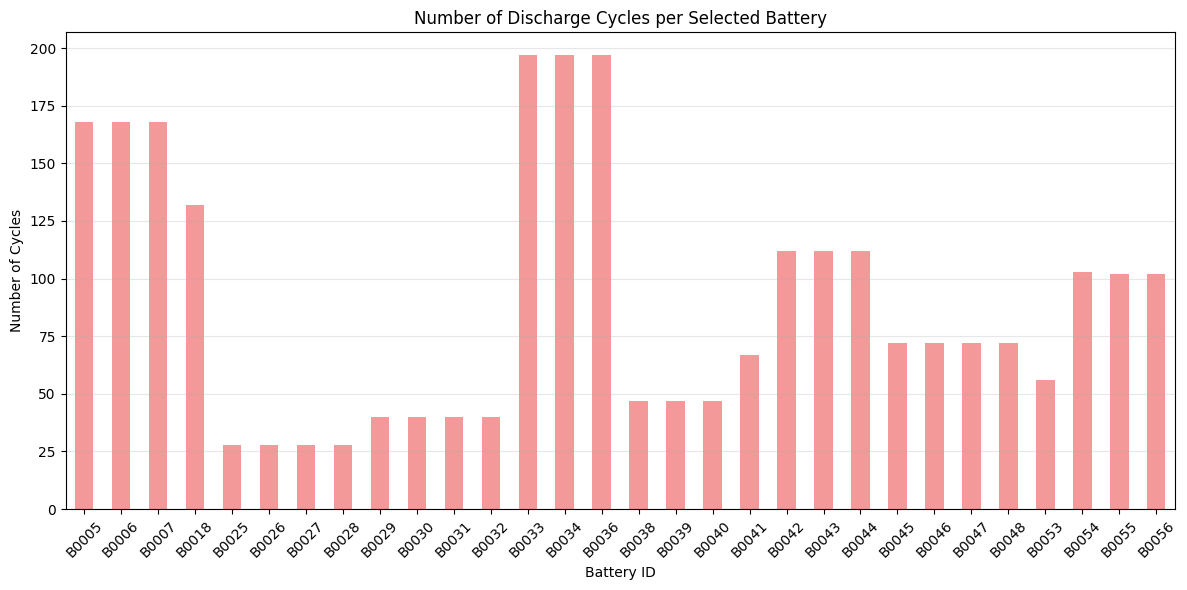

In [46]:
# Assign sequential cycle numbers per battery
filtered_metadata['cycle_number'] = filtered_metadata.groupby('battery_id').cumcount() + 1

# Analysis of cycle distribution
cycle_summary = filtered_metadata.groupby('battery_id').agg({
    'cycle_number': ['count', 'max'],
    'filename': 'first'
}).round(2)

cycle_summary.columns = ['total_cycles', 'max_cycle_num', 'first_file']
cycle_summary = cycle_summary.sort_values('total_cycles', ascending=False)

print("Cycle Distribution per Battery:")
display(cycle_summary)

# Visualize cycle distribution
plt.figure(figsize=(12, 6))
cycle_counts = filtered_metadata['battery_id'].value_counts().sort_index()
cycle_counts.plot(kind='bar', color='lightcoral', alpha=0.8)
plt.title('Number of Discharge Cycles per Selected Battery')
plt.xlabel('Battery ID')
plt.ylabel('Number of Cycles')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **5. Advanced Feature Engineering with Interpolation**

#### **5.1 Importing Additional Libraries**

In [14]:
# Import additional libraries for Interpolation
import os
from scipy.interpolate import interp1d
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

#### **5.2 Normalized Time**

**Objective:**

Load the cycle-level data for each battery in filtered_metadata and compute normalized time (between 0 and 1) for each cycle, which will be used later for interpolation.

In [17]:
# Compute SoH and normalized time per battery
def add_soh_and_normalized_time(df):
    df = df.copy()
    df['normalized_time'] = df['cycle_number'] / df['cycle_number'].max()
    df['initial_capacity'] = df.groupby('battery_id')['Capacity'].transform('first')
    df['SoH'] = df['Capacity'] / df['initial_capacity']
    return df

filtered_metadata = add_soh_and_normalized_time(filtered_metadata)

# Check a few rows
display(filtered_metadata.head())

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,cycle_number,normalized_time,initial_capacity,SoH
0,discharge,2010-07-21 15:00:35.093000,4,B0047,0,1,00001.csv,1.674305,NaN,NaN,1,0.005076,1.674305,1.000000
4,discharge,2010-07-21 21:02:56.984000,4,B0047,4,5,00005.csv,1.524366,NaN,NaN,2,0.010152,1.674305,0.910447
6,discharge,2010-07-22 01:40:06.217999,4,B0047,6,7,00007.csv,1.508076,NaN,NaN,3,0.015228,1.674305,0.900718
8,discharge,2010-07-22 06:16:21.780999,4,B0047,8,9,00009.csv,1.483558,NaN,NaN,4,0.020305,1.674305,0.886074
10,discharge,2010-07-22 10:51:48.203000,4,B0047,10,11,00011.csv,1.467139,NaN,NaN,5,0.025381,1.674305,0.876268


In [34]:
filtered_metadata[['battery_id', 'cycle_number', 'Capacity', 'normalized_time', 'SoH']].head(30)


,battery_id,cycle_number,Capacity,normalized_time,SoH
0,B0047,1,1.674305,0.005076,1.000000
4,B0047,2,1.524366,0.010152,0.910447
6,B0047,3,1.508076,0.015228,0.900718
8,B0047,4,1.483558,0.020305,0.886074
10,B0047,5,1.467139,0.025381,0.876268
12,B0047,6,1.448858,0.030457,0.865349
16,B0047,7,1.445853,0.035533,0.863555
20,B0047,8,1.431118,0.040609,0.854754
22,B0047,9,1.419275,0.045685,0.847680
24,B0047,10,1.399997,0.050761,0.836166


#### **5.3 Interpolation on Normalized Time Grid**

In [30]:
# Define common normalized time grid
normalized_time_grid = np.linspace(0, 1, 100)

interpolated_data = {}

for battery_id, group in filtered_metadata.groupby('battery_id'):
    # Sort by normalized_time to ensure smooth interpolation
    group_sorted = group.sort_values('normalized_time')

    # Drop duplicates if any
    group_sorted = group_sorted.drop_duplicates(subset='normalized_time')

    times = group_sorted['normalized_time'].values
    soh = group_sorted['SoH'].values

    # Ensure all values are finite (no NaNs or infs)
    if len(times) < 2 or np.any(~np.isfinite(soh)):
        continue  # Skip if not enough data or invalid

    # Interpolate
    interp_fn = interp1d(times, soh, kind='linear', fill_value='extrapolate')
    soh_interp = interp_fn(normalized_time_grid)

    interpolated_data[battery_id] = soh_interp


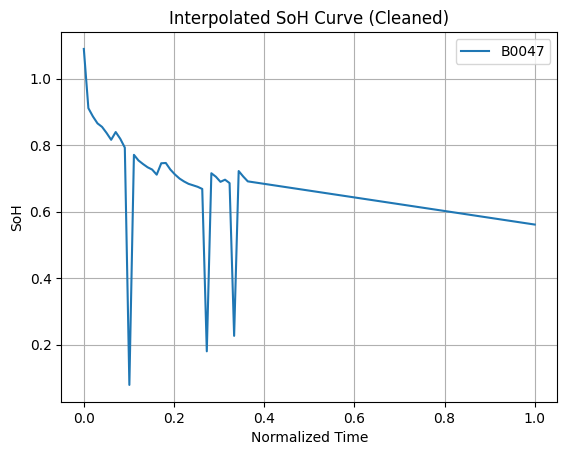

In [31]:
plt.plot(normalized_time_grid, interpolated_data['B0047'], label='B0047')
plt.title('Interpolated SoH Curve (Cleaned)')
plt.xlabel('Normalized Time')
plt.ylabel('SoH')
plt.grid(True)
plt.legend()
plt.show()
